# Diabetes Mortality Trends Analysis (1999-2020)

**Author:** Dany Drammeh  
**Date:** February 13th 2026  
**Data Source:** CDC WONDER (Wide-Ranging Online Data for Epidemiologic Research)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

In [2]:
# Read the CSV file
df = pd.read_csv('diabetes_mortality_data.csv')

# Clean up column names
df.columns = df.columns.str.strip()

# Rename columns to match analysis
df.rename(columns={
    'Sex': 'Gender',
    'Crude Rate': 'Crude_Rate'
}, inplace=True)

# Remove the 'Notes' column and any rows where it has data
if 'Notes' in df.columns:
    df = df.drop('Notes', axis=1)

# Convert Year, Deaths, Population to numeric
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Deaths'] = pd.to_numeric(df['Deaths'], errors='coerce')
df['Population'] = pd.to_numeric(df['Population'], errors='coerce')

# Handle 'Unreliable' values in Crude_Rate
df['Crude_Rate'] = pd.to_numeric(df['Crude_Rate'], errors='coerce')

# Calculate Crude_Rate if missing (when it was 'Unreliable')
df.loc[df['Crude_Rate'].isna(), 'Crude_Rate'] = (
    df.loc[df['Crude_Rate'].isna(), 'Deaths'] /
    df.loc[df['Crude_Rate'].isna(), 'Population']
) * 100000

# Remove rows with missing critical data
df = df.dropna(subset=['Year', 'Deaths', 'Population', 'Gender', 'Race'])

# Convert Year to integer
df['Year'] = df['Year'].astype(int)

df.head(10)

,Census Region,Census Region Code,Gender,Sex Code,Year,Year Code,Race,Race Code,Deaths,Population,Crude_Rate
0,Census Region 1: Northeast,CENS-R1,Female,F,1999,1999.0,American Indian or Alaska Native,1002-5,10.0,106823.0,9.361280
1,Census Region 1: Northeast,CENS-R1,Female,F,1999,1999.0,Asian or Pacific Islander,A-PI,72.0,1133752.0,6.400000
2,Census Region 1: Northeast,CENS-R1,Female,F,1999,1999.0,Black or African American,2054-5,1094.0,3597647.0,30.400000
3,Census Region 1: Northeast,CENS-R1,Female,F,1999,1999.0,White,2106-3,5869.0,22733874.0,25.800000
4,Census Region 1: Northeast,CENS-R1,Female,F,2000,2000.0,American Indian or Alaska Native,1002-5,17.0,114584.0,14.836277
5,Census Region 1: Northeast,CENS-R1,Female,F,2000,2000.0,Asian or Pacific Islander,A-PI,77.0,1174043.0,6.600000
6,Census Region 1: Northeast,CENS-R1,Female,F,2000,2000.0,Black or African American,2054-5,1121.0,3633620.0,30.900000
7,Census Region 1: Northeast,CENS-R1,Female,F,2000,2000.0,White,2106-3,6030.0,22774804.0,26.500000
8,Census Region 1: Northeast,CENS-R1,Female,F,2001,2001.0,American Indian or Alaska Native,1002-5,14.0,123794.0,11.309110
9,Census Region 1: Northeast,CENS-R1,Female,F,2001,2001.0,Asian or Pacific Islander,A-PI,74.0,1248135.0,5.900000


In [3]:
# Aggregate by year
yearly_trends = df.groupby('Year').agg({
    'Deaths': 'sum',
    'Population': 'sum'
}).reset_index()
yearly_trends['Mortality_Rate'] = (yearly_trends['Deaths'] / yearly_trends['Population']) * 100000

print("Yearly Mortality Trends:")
yearly_trends

Yearly Mortality Trends:


,Year,Deaths,Population,Mortality_Rate
0,1999,68399.0,279040168.0,24.512242
1,2000,69292.0,281308332.0,24.632047
2,2001,71372.0,284968955.0,25.045535
3,2002,73249.0,287625193.0,25.466823
4,2003,74219.0,290107933.0,25.583237
5,2004,73131.0,292656756.0,24.988659
6,2005,75119.0,295516599.0,25.419554
7,2006,72449.0,298379912.0,24.280790
8,2007,71376.0,301057828.0,23.708402
9,2008,70553.0,304093966.0,23.201052


In [4]:
# Calculate percent change
first_year_rate = yearly_trends.iloc[0]['Mortality_Rate']
last_year_rate = yearly_trends.iloc[-1]['Mortality_Rate']
percent_change = ((last_year_rate - first_year_rate) / first_year_rate) * 100

print(f"First Year ({yearly_trends.iloc[0]['Year']}) Rate: {first_year_rate:.2f} per 100K")
print(f"Last Year ({yearly_trends.iloc[-1]['Year']}) Rate: {last_year_rate:.2f} per 100K")
print(f"Total Change: {percent_change:.1f}%")

First Year (1999.0) Rate: 24.51 per 100K
Last Year (2020.0) Rate: 31.01 per 100K
Total Change: 26.5%


In [5]:
# Gender analysis
print("MORTALITY BY GENDER:")
print("-" * 80)
gender_analysis = df.groupby('Gender').agg({
    'Deaths': 'sum',
    'Population': 'sum'
}).reset_index()
gender_analysis['Mortality_Rate'] = (gender_analysis['Deaths'] / gender_analysis['Population']) * 100000
print(gender_analysis)

male_rate = gender_analysis[gender_analysis['Gender'] == 'Male']['Mortality_Rate'].values[0]
female_rate = gender_analysis[gender_analysis['Gender'] == 'Female']['Mortality_Rate'].values[0]
gender_ratio = male_rate / female_rate
print(f"\nMale to Female Mortality Ratio: {gender_ratio:.2f}x")
print(f"Males have {((gender_ratio - 1) * 100):.1f}% higher mortality rate than females")

MORTALITY BY GENDER:
--------------------------------------------------------------------------------
   Gender    Deaths    Population  Mortality_Rate
0  Female  814549.0  3.428441e+09       23.758585
1    Male  860130.0  3.316863e+09       25.932030

Male to Female Mortality Ratio: 1.09x
Males have 9.1% higher mortality rate than females


In [6]:
# Race analysis
print("MORTALITY BY RACE:")
print("-" * 80)
race_analysis = df.groupby('Race').agg({
    'Deaths': 'sum',
    'Population': 'sum'
}).reset_index()
race_analysis['Mortality_Rate'] = (race_analysis['Deaths'] / race_analysis['Population']) * 100000
race_analysis = race_analysis.sort_values('Mortality_Rate', ascending=False)
race_analysis

MORTALITY BY RACE:
--------------------------------------------------------------------------------


,Race,Deaths,Population,Mortality_Rate
2,Black or African American,295826.0,9.190349e+08,32.188765
3,White,1312420.0,5.367045e+09,24.453307
0,American Indian or Alaska Native,19970.0,8.731002e+07,22.872517
1,Asian or Pacific Islander,46463.0,3.719141e+08,12.492940


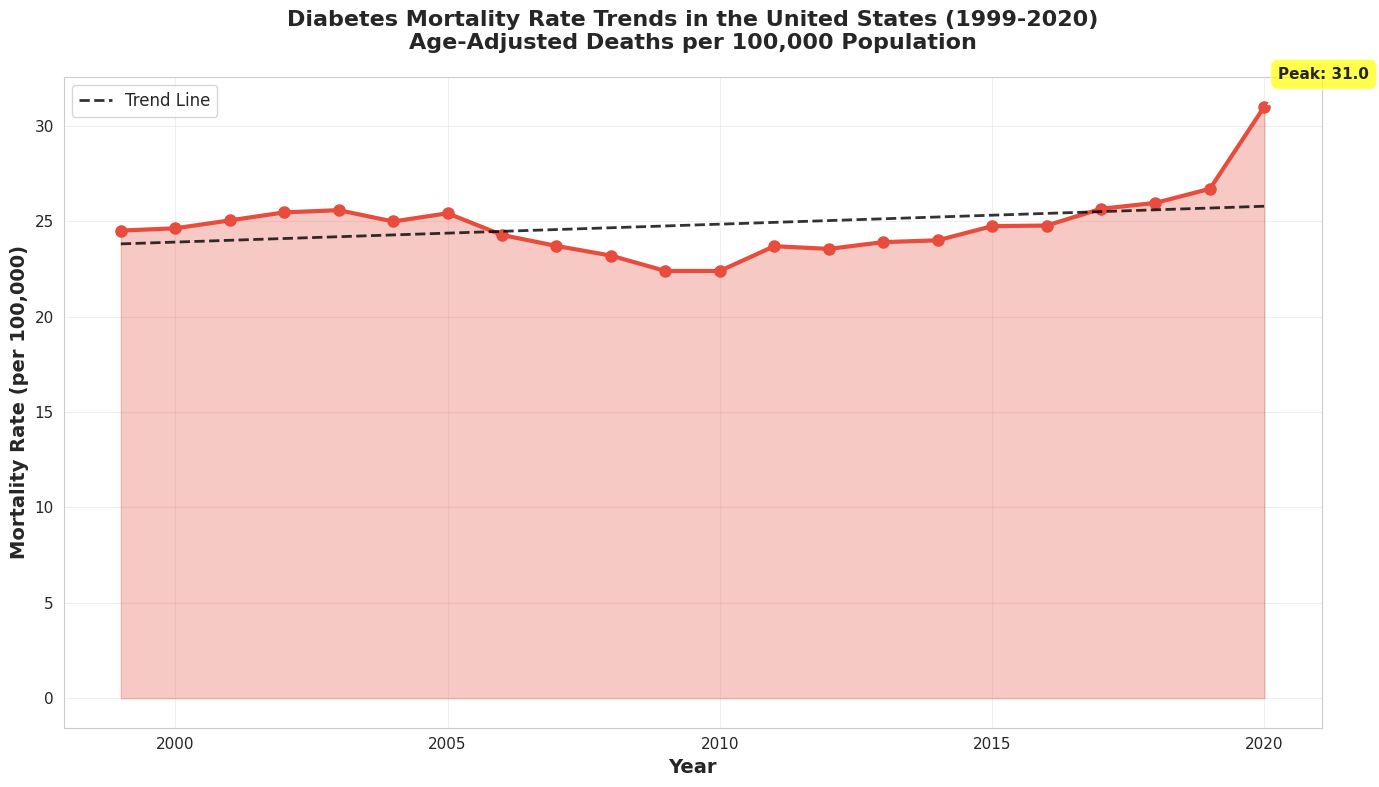

In [7]:
plt.figure(figsize=(14, 8))
plt.plot(yearly_trends['Year'], yearly_trends['Mortality_Rate'],
         marker='o', linewidth=3, markersize=8, color='#e74c3c')
plt.fill_between(yearly_trends['Year'], yearly_trends['Mortality_Rate'],
                  alpha=0.3, color='#e74c3c')

# Add trend line
z = np.polyfit(yearly_trends['Year'], yearly_trends['Mortality_Rate'], 1)
p = np.poly1d(z)
plt.plot(yearly_trends['Year'], p(yearly_trends['Year']),
         "--", alpha=0.8, linewidth=2, color='black', label='Trend Line')

plt.title('Diabetes Mortality Rate Trends in the United States (1999-2020)\n' +
          'Age-Adjusted Deaths per 100,000 Population',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14, fontweight='bold')
plt.ylabel('Mortality Rate (per 100,000)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Add annotation for peak
max_year = yearly_trends.loc[yearly_trends['Mortality_Rate'].idxmax()]
plt.annotate(f"Peak: {max_year['Mortality_Rate']:.1f}",
            xy=(max_year['Year'], max_year['Mortality_Rate']),
            xytext=(10, 20), textcoords='offset points',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

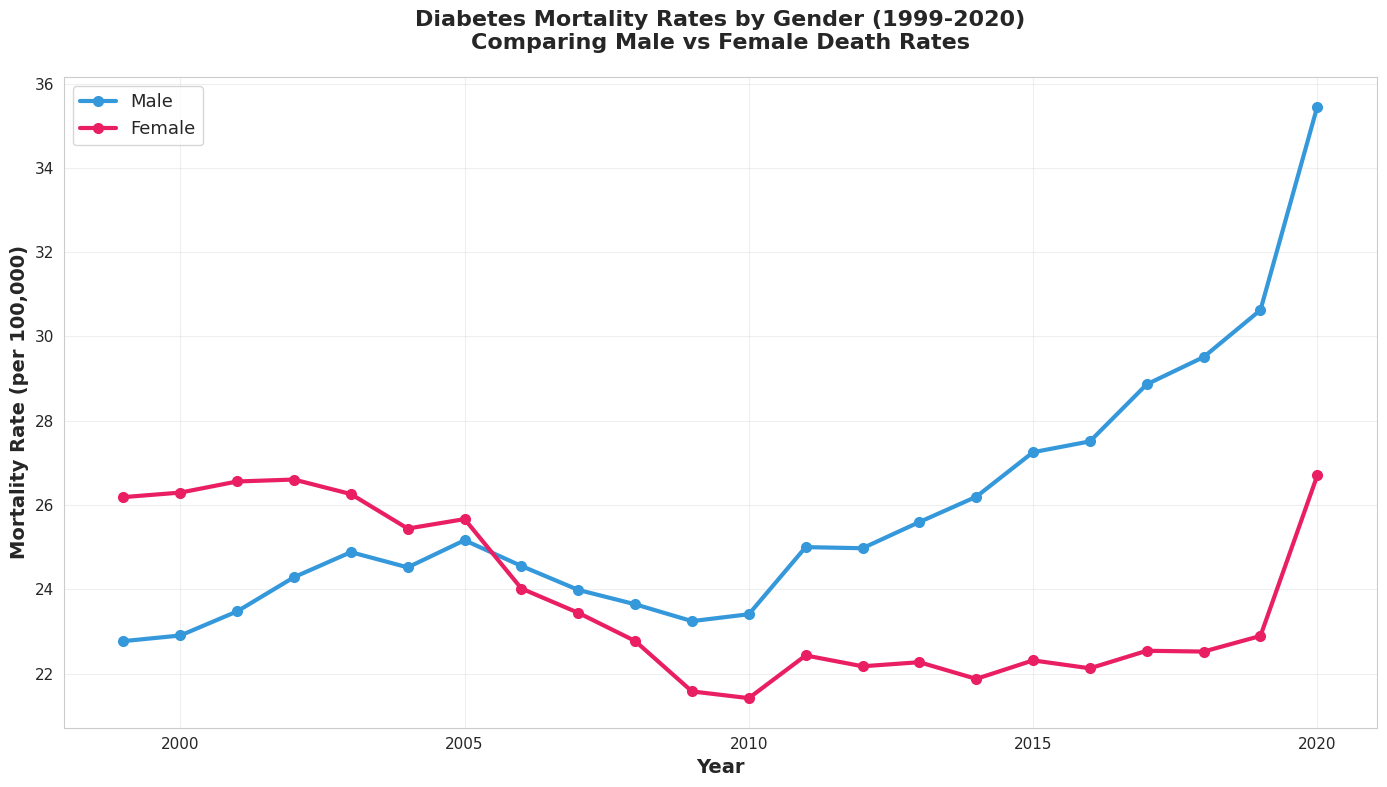

In [8]:
plt.figure(figsize=(14, 8))

gender_trends = df.groupby(['Year', 'Gender']).agg({
    'Deaths': 'sum',
    'Population': 'sum'
}).reset_index()
gender_trends['Mortality_Rate'] = (gender_trends['Deaths'] / gender_trends['Population']) * 100000

for gender in ['Male', 'Female']:
    data = gender_trends[gender_trends['Gender'] == gender]
    color = '#3498db' if gender == 'Male' else '#e91e63'
    plt.plot(data['Year'], data['Mortality_Rate'],
            marker='o', linewidth=3, markersize=7, label=gender, color=color)

plt.title('Diabetes Mortality Rates by Gender (1999-2020)\n' +
          'Comparing Male vs Female Death Rates',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14, fontweight='bold')
plt.ylabel('Mortality Rate (per 100,000)', fontsize=14, fontweight='bold')
plt.legend(fontsize=13, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

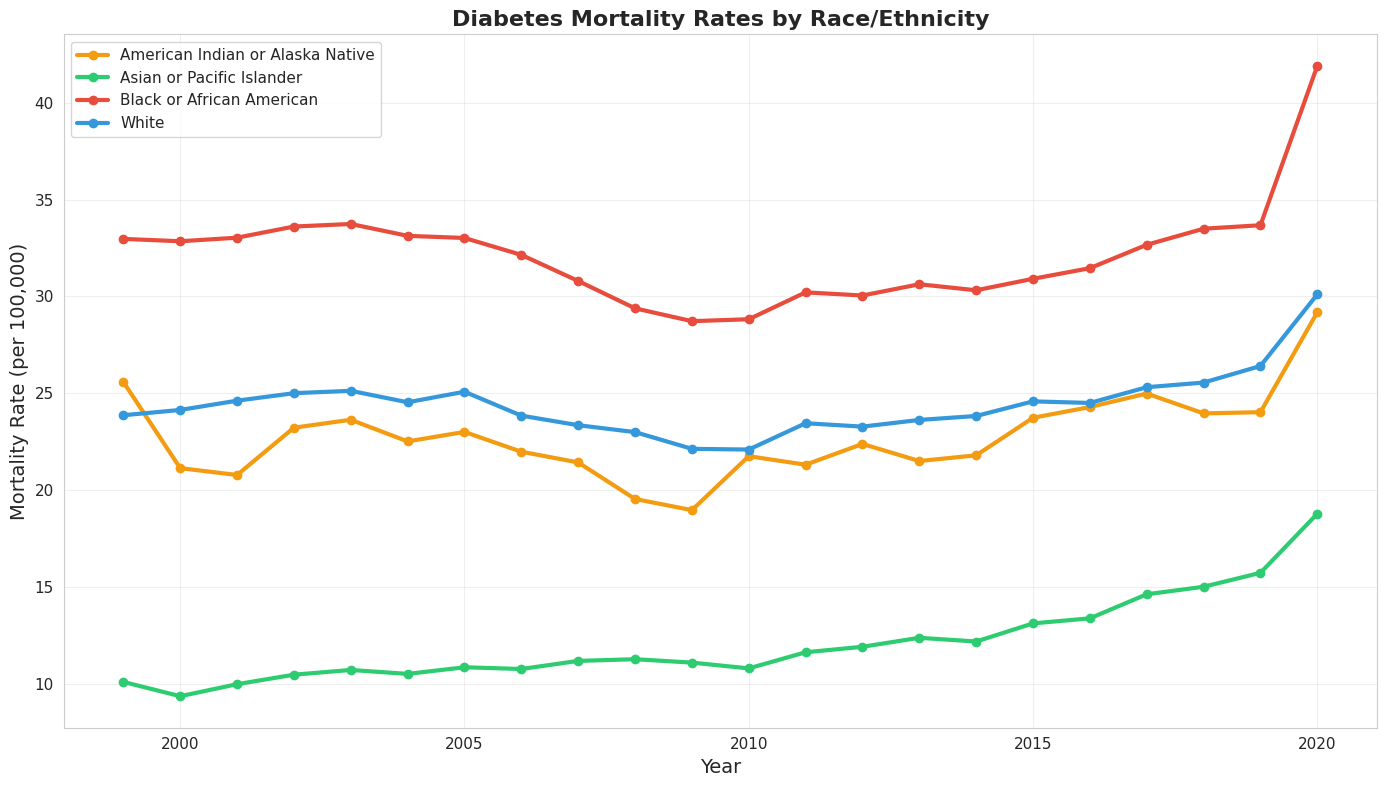

In [9]:
plt.figure(figsize=(14, 8))

race_trends = df.groupby(['Year', 'Race']).agg({
    'Deaths': 'sum',
    'Population': 'sum'
}).reset_index()
race_trends['Mortality_Rate'] = (race_trends['Deaths'] / race_trends['Population']) * 100000

colors = {'White': '#3498db', 'Black or African American': '#e74c3c',
          'Asian or Pacific Islander': '#2ecc71',
          'American Indian or Alaska Native': '#f39c12'}

for race in race_trends['Race'].unique():
    data = race_trends[race_trends['Race'] == race]
    color = colors.get(race, '#95a5a6')
    plt.plot(data['Year'], data['Mortality_Rate'],
            marker='o', linewidth=3, label=race, color=color)

plt.title('Diabetes Mortality Rates by Race/Ethnicity', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Mortality Rate (per 100,000)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

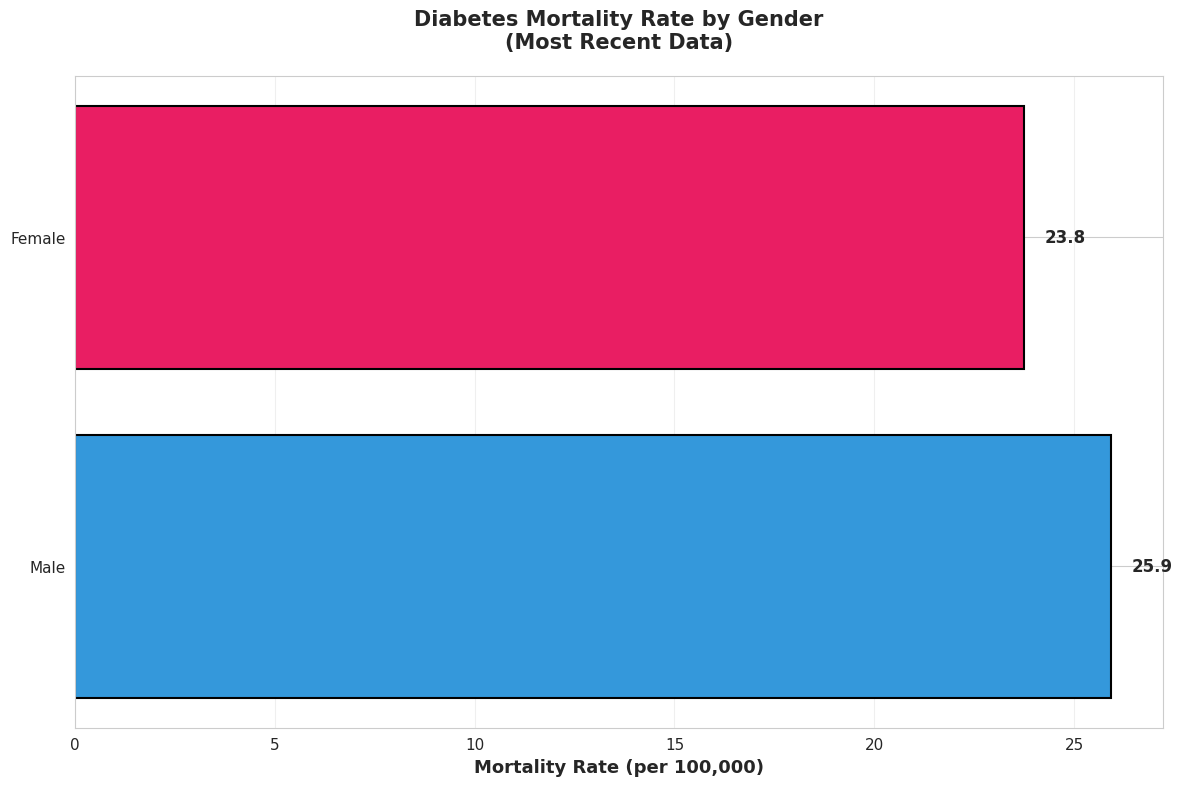

In [10]:
plt.figure(figsize=(12, 8))

gender_sorted = gender_analysis.sort_values('Mortality_Rate', ascending=False)
colors_gender = ['#3498db', '#e91e63']
bars = plt.barh(range(len(gender_sorted)), gender_sorted['Mortality_Rate'],
                color=colors_gender, edgecolor='black', linewidth=1.5)

plt.yticks(range(len(gender_sorted)), gender_sorted['Gender'])
plt.xlabel('Mortality Rate (per 100,000)', fontsize=13, fontweight='bold')
plt.title('Diabetes Mortality Rate by Gender\n(Most Recent Data)',
          fontsize=15, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(gender_sorted.iterrows()):
    plt.text(row['Mortality_Rate'] + 0.5, i, f"{row['Mortality_Rate']:.1f}",
            va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

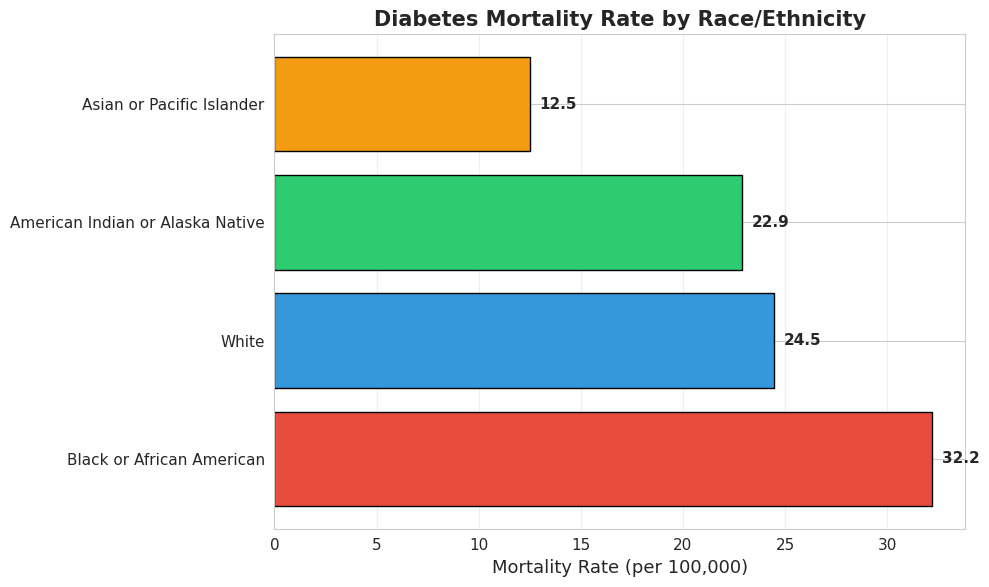

In [11]:
plt.figure(figsize=(10, 6))

race_sorted = race_analysis.sort_values('Mortality_Rate', ascending=False)
colors_race = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

plt.barh(race_sorted['Race'], race_sorted['Mortality_Rate'],
         color=colors_race[:len(race_sorted)], edgecolor='black')

plt.xlabel('Mortality Rate (per 100,000)', fontsize=13)
plt.title('Diabetes Mortality Rate by Race/Ethnicity', fontsize=15, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(race_sorted.iterrows()):
    plt.text(row['Mortality_Rate'] + 0.5, i, f"{row['Mortality_Rate']:.1f}",
            va='center', fontweight='bold')

plt.tight_layout()
plt.show()